## **Modelagem: Regressão Logística**

Neste notebook vamos construir e testar um modelo de regressão logística para prever os funcionários que pedirão demissão voluntária. Nosso objetivo é conseguir detectar o máximo possível de funcionários "em risco" de demissão voluntária, bem como descobrir os fatores potencialmente responsáveis por essas demissões. Isso significa que queremos alcançar um bom `recall` e usar técnicas de interpretabilidade para compreender como nosso modelo faz predições. 

A regressão logística será nosso primeiro modelo e servirá como baseline para os demais, i.e., se nenhum outro modelo for significativamente superior a ela, esta será a melhor opção. Isso porque a regressão logística é rápida para treinar e altamente interpretável. 

O processo de modelagem seguirá as seguintes etapas:

- **Pipeline de transformações**: vamos definir um pipeline de transformadores para preparar nossos dados.

- **Tuning do modelo**: vamos usar 10 dobras de validação cruzada para treinar e validar 150 modelos de regressão diferentes, com hiperparâmetros aleatóriamente escolhido no espaço de parâmetros possíveis. Vamos optar pelo modelo que melhor equilibra `recall` e `roc_auc`. 

- **Treinamento do melhor modelo**: vamos selecionar os hiperparâmetros do melhor modelo e treiná-lo no conjunto completo de treinamento

- **Métricas de avaliação no treinamento**: vamos avaliar a acurácia, curva ROC, precisão, recall e f1-score no conjunto de treinamento.

- **Tuning do limiar de decisão**: um modelo de regressão logística gera probabilidades de classe. Assim, para fazer classificações, precisamos usar um limiar ("threshold") para a classe positiva. As avaliações base do modelo usam um limiar de 0.5, mas é possível tunarmos esse valor.

---

Obs: A análise da interpretabiliade será feita com o modelo final escolhido, bem como o teste no conjunto de testes. 


## Importação de Bibliotecas

Nesta etapa são importadas todas as bibliotecas necessárias para **pré-processamento, modelagem e busca de hiperparâmetros**:

1. **Bibliotecas gerais**
   - `numpy` e `pandas`: manipulação de arrays e DataFrames.  
   - `matplotlib.pyplot`: geração de gráficos.  
   - `joblib`: salvar e carregar objetos treinados (como modelos e pipelines).

2. **Transformadores (scikit-learn)**
   - `ColumnTransformer`: aplica diferentes transformações a grupos de colunas.  
   - `OneHotEncoder`, `OrdinalEncoder`, `StandardScaler`, `TargetEncoder`: transformações para variáveis categóricas, ordinais e numéricas.  
   - `PolynomialFeatures`: cria novas features polinomiais a partir das originais.  
   - `KNNImputer`: imputação de valores ausentes com base nos vizinhos mais próximos.  
   - `Pipeline`: encadeia as etapas de pré-processamento e modelagem.

3. **Modelos**
   - `LogisticRegression`: modelo estatístico base usado para classificação.

4. **Busca de hiperparâmetros**
   - `loguniform`, `uniform`: distribuições de probabilidade usadas para amostragem de hiperparâmetros.  
   - `RandomizedSearchCV`: busca aleatória sobre o espaço de hiperparâmetros, combinando treino e validação cruzada.

---

👉 Essas importações organizam as ferramentas que serão usadas para **construir, ajustar e otimizar** o pipeline de machine learning.


In [1]:
### libs ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

### Transformadores ###

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder, PolynomialFeatures
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

### Modelos ###

from sklearn.linear_model import LogisticRegression


### Randomized Search ###
from scipy.stats import loguniform, uniform
from sklearn.model_selection import RandomizedSearchCV


In [2]:
#Regressão logística polinomial regularizada

## Carregamento dos Dados de Treino

Neste passo, os arquivos de treino previamente salvos em **CSV** são carregados para o ambiente:

1. **`X_train.csv`**  
   - Contém as variáveis preditoras (features) já separadas para treino.  
   - É lido em um DataFrame `X_train`.

2. **`y_train.csv`**  
   - Contém apenas a variável alvo (target), indicando o desfecho que se deseja prever.  
   - É lido em um DataFrame `y_train`.

---

👉 Esses arquivos foram gerados anteriormente no processo de preparação dos dados (divisão treino/teste) e agora serão usados como entrada para o pipeline de modelagem.


In [3]:
# Carregar os dados
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")


## Verificação de Desbalanceamento do Alvo

Este trecho avalia a **distribuição da variável alvo** (`y_train`) no conjunto de treino:

1. **Transformação em DataFrame**  
   - O vetor `y_train` é convertido em um DataFrame para facilitar a contagem.

2. **Contagem de classes**  
   - `value_counts(normalize=True)` conta quantas vezes cada classe aparece e retorna a **proporção relativa** (em vez do número absoluto).

3. **Resultado esperado**  
   - Exibe as classes do alvo (ex.: `0 = sem asma`, `1 = com asma`) e a porcentagem de cada uma.  
   - Se uma classe tiver uma proporção muito maior que a outra, significa que há **desbalanceamento**, o que pode impactar o desempenho dos modelos.

---

👉 Essa análise é fundamental para decidir se será necessário aplicar técnicas como **class_weight**, **oversampling (SMOTE)** ou **undersampling** para corrigir o desbalanceamento.


In [4]:
# Verificar desbalanceamento do alvo no CSV
pd.DataFrame(y_train).value_counts(normalize=True)


num_asma
0.0         0.950823
1.0         0.049177
Name: proportion, dtype: float64

## Análise de Valores Ausentes (Missing Data)

Este bloco realiza uma análise exploratória dos **valores ausentes** no conjunto de treino (`X_train`):

1. **Cálculo da taxa de ausência**  
   - Para cada coluna, calcula-se a proporção de valores faltantes (`NaN`) em relação ao total de linhas.  
   - O resultado é armazenado no DataFrame `nas`, na coluna `missing_rate`.

2. **Ordenação**  
   - As variáveis são ordenadas da maior para a menor taxa de valores ausentes.  
   - Assim, fica mais fácil identificar quais colunas têm maior problema de dados faltantes.

3. **Visualização**  
   - Mostra as **15 colunas com mais valores ausentes** (`nas.head(15)`).  
   - Se houver menos de 15 colunas no dataset, exibirá apenas as existentes.

---

👉 Essa análise é importante para decidir **estratégias de imputação ou exclusão** de variáveis/linhas, garantindo melhor qualidade nos modelos.


In [5]:
# Analise de Missing:
# calcula proporção de valores ausentes em cada coluna
nas = pd.DataFrame((X_train.isna().sum() / len(X_train)), columns=["missing_rate"])

# ordena do maior para o menor
nas = nas.sort_values("missing_rate", ascending=False)

# mostra as 30 piores (se tiver tantas)
nas.head(15)


,missing_rate
ord_remedio_sus,0.992804
ord_farmacia_popular,0.991056
catl_pagou_remedio,0.991056
ord_remedio_semana,0.984355
catl_aerossol_asma,0.984355
catl_remedio_asma,0.981851
catl_recebeu_atendimento,0.970073
ord_limita_asma,0.950823
num_idade_diagnostico,0.950823
catl_crise_asma,0.950823


## Definição dos Grupos de Variáveis

Neste trecho, organizamos todas as colunas do dataset em **grupos de variáveis** de acordo com sua natureza.  
Essa separação facilita o pré-processamento, pois cada tipo de variável exige um tratamento diferente no pipeline.

### Grupos criados:

- **Binárias (`binarias`)**  
  Variáveis com apenas duas categorias possíveis (ex.: *sim/não*, *masculino/feminino*).  
  Exemplos: `catl_sexo`, `catl_doenca_cronica`, `catl_cigarro`.

- **Numéricas (`numericas`)**  
  Variáveis quantitativas contínuas ou discretas que já estão em formato numérico.  
  Exemplos: `num_idade`, `num_idade_diagnostico`, `num_consultas`.

- **Ordinais (`ordinais`)**  
  Variáveis categóricas que possuem **ordem natural** entre as categorias (ex.: níveis de saúde ou de cobertura).  
  Exemplos: `ord_saude`, `ord_limita_asma`, `ord_nivel_plano`.

- **Categóricas (`categoricas`)**  
  Variáveis qualitativas **sem ordem definida** entre as categorias.  
  Exemplos: `catl_cor_raca`, `catl_tipo_de_area`, `cath_material_parede`.

---

👉 Essa estrutura (`tipos_variaveis1`) será usada no **ColumnTransformer** do pipeline para aplicar transformações específicas em cada grupo de variáveis.


In [6]:
# 1) Grupos de variáveis
tipos_variaveis1 = {
    "binarias": [
        "catl_sexo","catl_doenca_cronica","catl_animais","catl_homeopatia",
        "catl_internacao","catl_quimicos","catl_ruidos","catl_sol",
        "catl_material_biologico","catl_plano_saude","catl_medicamentos",
        "catl_plantas_medicinais","catl_deixar_atividades","catl_servico_saude",
        "catl_recebeu_atendimento","catl_lixo","catl_poeira_mineral",
        "catl_plano_consultas","catl_plano_exames","catl_plano_internacoes",
        "catl_crise_asma","catl_remedio_asma","catl_aerossol_asma",
        "catl_cigarro","catl_pagou_remedio","catl_domicilio_cadastrado"
    ],

    "numericas": [
        "num_idade","catl_cachoros","catl_gatos",
        "num_idade_diagnostico","num_consultas"
    ],

    "ordinais": [
        "ord_saude","ord_limita_asma","ord_agente_saude",
        "ord_nivel_plano","ord_remedio_semana","ord_remedio_sus",
        "ord_farmacia_popular"
    ],

    "categoricas": [
        "catl_cor_raca","catl_tipo_de_area","catl_tipo_de_domicilio",
        "cath_material_parede","cath_fonte_de_agua",
        "catl_destino_do_lixo","catl_atividade","cath_estado_agua",
        "cath_local_atendimento"
    ],

    "alta_cardinalidade": [
        "cath_destino_do_esgoto","cath_trabalho"
    ]
}


## Pipeline de Pré-Processamento e Busca de Hiperparâmetros

Este bloco de código constrói um **pipeline completo** para treinar uma Regressão Logística regularizada com **penalização elastic net**, incluindo pré-processamento dos dados e ajuste de hiperparâmetros.

### Principais etapas:

1. **Importação de bibliotecas**  
   - Usa `scikit-learn` para pipelines, pré-processamento, modelos e validação cruzada.  
   - Usa `scipy.stats.loguniform` para amostrar valores de `C` (força da regularização).

2. **Codificação de variáveis categóricas (OneHotEncoder)**  
   - Implementado de forma **compatível com diferentes versões do scikit-learn**.  
   - `OHE_BIN`: trata variáveis binárias (gera apenas uma coluna).  
   - `OHE_CAT`: trata variáveis categóricas com múltiplas classes.

3. **Pipelines de pré-processamento por tipo de variável**  
   - **Numéricas**: imputação com `KNNImputer` + padronização com `StandardScaler`.  
   - **Ordinais**: imputação com moda + `OrdinalEncoder`.  
   - **Binárias**: imputação com moda + `OneHotEncoder` para binárias.  
   - **Categóricas**: imputação com moda + `OneHotEncoder` completo.

4. **Combinação dos pipelines**  
   - `ColumnTransformer` reúne todos os blocos de pré-processamento em paralelo.  
   - Apenas as colunas definidas em `tipos_variaveis1` são transformadas.

5. **Modelo**  
   - `LogisticRegression` com `solver="saga"` (necessário para elastic net).  
   - `penalty="elasticnet"` com valor inicial de `l1_ratio=0.5`.  
   - Configurado para até 1000 iterações, tolerância de 1e-3 e uso de múltiplos núcleos (`n_jobs=-1`).

6. **Busca de hiperparâmetros (RandomizedSearchCV)**  
   - `clf__C`: força da regularização (amostrada log-uniformemente entre 0.01 e 10).  
   - `clf__l1_ratio`: mistura entre L1 e L2 (valores pré-definidos de 0.1 a 0.9).  
   - `clf__class_weight`: testando tanto sem peso quanto balanceado.  
   - Configurações da busca:
     - `n_iter=22`: número de combinações aleatórias testadas.  
     - `cv=3`: validação cruzada mais leve.  
     - Métricas: **AUC**, **acurácia** e **revocação**, usando AUC como critério principal (`refit="roc_auc"`).  
     - `n_jobs=-1`: utiliza todos os núcleos disponíveis.

7. **Treinamento**  
   - O `RandomizedSearchCV` é ajustado diretamente sobre `X_train` e `y_train`, já passando pelo pipeline completo.  
   - Ao final, `random_search2` conterá o melhor modelo encontrado e os resultados da busca.

---
👉 Este pipeline garante **robustez**, **compatibilidade** e **bom desempenho**, sem sobrecarregar tanto a máquina.


In [8]:
from sklearn.impute import  SimpleImputer
# OneHot compatível (usa esparso quando fizer sentido)
ohe_kwargs = dict(handle_unknown="ignore", dtype=np.float32)
try:
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse_output=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse_output=True, **ohe_kwargs)
except TypeError:  # sklearn<1.2
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse=True, **ohe_kwargs)

# ---- Pipelines ----
num_pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=7)),
    ("scaler", StandardScaler())
])

ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_BIN)
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_CAT)
])

high_card_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target", TargetEncoder())
])



pre = ColumnTransformer(
    transformers=[
        ("numeric",     num_pipe, tipos_variaveis1["numericas"]),
        ("ordinal",     ord_pipe, tipos_variaveis1["ordinais"]),
        ("binary",      bin_pipe, tipos_variaveis1["binarias"]),
        ("categorical", cat_pipe, tipos_variaveis1["categoricas"]),
        ("high_card",   high_card_pipe, tipos_variaveis1["alta_cardinalidade"]),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
    # IMPORTANTE: não force esparso aqui; deixe o CT decidir
    # sparse_threshold=0.3  # (padrão). Pode omitir.
)

In [9]:

# 1) y 1D
y_train1d = np.ravel(y_train)

# 2) modelo base
clf = LogisticRegression(
    solver="saga",
    penalty="elasticnet",
    l1_ratio=0.5,
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

# 3) pipeline: preprocessamento + modelo
pipe = Pipeline([
    ("pre", pre),   # seu ColumnTransformer já definido com num/ord/bin/cat/high_card
    ("clf", clf)
])

# 4) distribuição de hiperparâmetros (use prefixo clf__)
param_distributions = {
    "clf__C": loguniform(1e-2, 10),
    "clf__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    "clf__class_weight": [None, "balanced"],
}

# 5) busca
random_search2 = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,                     # estratificado por padrão
    random_state=42,
    n_jobs=-1,
    verbose=2,
    scoring=["roc_auc", "accuracy", "recall"],
    refit="roc_auc",
)

# 6) treinar SEM transformar antes (o pipe cuida de tudo por fold)
random_search2.fit(X_train, y_train1d)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('pre',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                KNNImputer(n_neighbors=7)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['num_idade',
                                                                                'catl_cachoros',
                                                                                'catl_gatos',
                                                                                'num_idade_diagnostico',
                                                                                'num_consultas']),
                                                                              ('ordinal',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('e...
                                                                 penalty='elasticnet',
                                                                 random_state=42,
                                                                 solver='saga',
                                                                 tol=0.001))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'clf__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000220BF226AC0>,
                                        'clf__class_weight': [None, 'balanced'],
                                        'clf__l1_ratio': [0.1, 0.3, 0.5, 0.7,
                                                          0.9]},
                   random_state=42, refit='roc_auc',
                   scoring=['roc_auc', 'accuracy', 'recall'], verbose=2)

### 💾 Salvando o objeto RandomizedSearchCV

Após finalizar o treinamento, podemos salvar o objeto `RandomizedSearchCV` completo com todos
os resultados e o melhor modelo encontrado.  
Isso permite carregar o objeto no futuro sem precisar refazer toda a busca.


In [10]:
# salvar objeto randomized search completo
joblib.dump(random_search2, 'logreg_random_search.joblib')

['logreg_random_search.joblib']

### 📂 Carregando o objeto RandomizedSearchCV salvo

Caso já tenhamos salvo o resultado da busca em disco (`.joblib`), 
podemos recarregar o objeto completo usando `joblib.load()`.  
Isso evita ter que rodar novamente toda a busca de hiperparâmetros.


In [11]:
# carregar objeto randomized search completo
random_search2 = joblib.load('logreg_random_search.joblib')

## **Avaliação dos modelos treinados**

Vamos analisar os resultados obtidos para os modelos a partir dos valores de `accuracy`, `roc_auc` e `recall`. Escolheremos o modelo com melhor `roc_auc` e `recall`. 

In [12]:
# ver resultados
results_vars = [
    "mean_test_roc_auc",
    "mean_test_accuracy",
    "mean_test_recall",
    "rank_test_roc_auc",
    "rank_test_accuracy",
    "rank_test_recall"
                ]

resultados_search = pd.DataFrame(random_search2.cv_results_)

resultados_search[results_vars]

,mean_test_roc_auc,mean_test_accuracy,mean_test_recall,rank_test_roc_auc,rank_test_accuracy,rank_test_recall
0,0.898847,0.968958,0.368776,2,13,40
1,0.898562,0.968972,0.369056,17,6,33
2,0.898334,0.968876,0.367098,22,19,46
3,0.897226,0.758091,0.825969,43,29,22
4,0.898709,0.750014,0.837997,10,50,1
5,0.897215,0.758077,0.825969,46,30,22
6,0.898177,0.755559,0.831563,27,42,10
7,0.897424,0.757816,0.827927,37,35,16
8,0.898769,0.968931,0.368217,5,16,43
9,0.898731,0.751445,0.835759,8,48,2


### 📊 Analisando os resultados do RandomizedSearchCV

Para comparar diferentes modelos de forma mais justa, podemos combinar os **ranks**
das métricas `roc_auc` e `recall`.  

- Criamos uma nova coluna `score` que representa a soma dos ranks dessas métricas.  
- Depois ordenamos os resultados de forma que os modelos com **menor score** 
  (melhor posição média entre as métricas) apareçam primeiro.


In [13]:
# soma dos ranks
resultados_search["score"] = resultados_search.rank_test_roc_auc + resultados_search.rank_test_recall

# minimizar a soma dos ranks
resultados_search.sort_values(by="score")[results_vars]

,mean_test_roc_auc,mean_test_accuracy,mean_test_recall,rank_test_roc_auc,rank_test_accuracy,rank_test_recall
9,0.898731,0.751445,0.835759,8,48,2
4,0.898709,0.750014,0.837997,10,50,1
47,0.898698,0.751720,0.835759,12,47,2
22,0.898698,0.750096,0.835479,11,49,4
28,0.898288,0.754568,0.833242,23,44,5
29,0.898287,0.754568,0.833242,25,44,5
15,0.898287,0.754376,0.832682,24,46,7
48,0.898202,0.754912,0.831843,26,43,8
35,0.898788,0.968972,0.369056,3,6,33
43,0.898776,0.968972,0.369056,4,6,33


### 🔧 Parâmetros do modelo selecionado

Após ordenar os resultados e identificar o melhor candidato, 
podemos inspecionar os **hiperparâmetros escolhidos** pelo `RandomizedSearchCV`.  

Isso permite verificar quais configurações levaram ao melhor desempenho
e documentar os ajustes do modelo.


In [14]:
# parâmetros do modelo escolhido
best_params = resultados_search["params"][9]

best_params

{'clf__C': np.float64(0.013803746963532811),
 'clf__class_weight': 'balanced',
 'clf__l1_ratio': 0.5}

### ⏱️ Tempo de execução do melhor modelo

Além das métricas de desempenho, é importante avaliar o **custo computacional**.  
Aqui verificamos os tempos médios de ajuste (`mean_fit_time`) e de predição 
(`mean_score_time`) do modelo que obteve o melhor rank em `roc_auc`.


In [15]:
# tempo de treinamento e pontuação do modelo escolhido
resultados_search[["mean_fit_time", "mean_score_time"]].iloc[9,]

mean_fit_time      318.8660
mean_score_time    154.5342
Name: 9, dtype: float64

### ⚙️ Aplicando os melhores parâmetros ao pipeline

Após identificar os hiperparâmetros ótimos com o `RandomizedSearchCV`,  
podemos repassá-los diretamente ao pipeline.  

- `random_search2.best_params_` retorna o dicionário com os parâmetros encontrados.  
- `pipeline.set_params(**best_params)` aplica essas configurações ao pipeline,  
  deixando-o pronto para ser treinado ou reutilizado com os melhores ajustes.


In [17]:
# definir parâmetros para o pipeline
pipe.set_params(**best_params)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=7)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_idade', 'catl_cachoros',
                                                   'catl_gatos',
                                                   'num_idade_diagnostico',
                                                   'num_consultas']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown=...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target',
                                                                   TargetEncoder())]),
                                                  ['cath_destino_do_esgoto',
                                                   'cath_trabalho'])],
                                   verbose_feature_names_out=False)),
                ('clf',
                 LogisticRegression(C=np.float64(0.013803746963532811),
                                    class_weight='balanced', l1_ratio=0.5,
                                    max_iter=1000, penalty='elasticnet',
                                    random_state=42, solver='saga',
                                    tol=0.001))])

### 🏋️‍♂️ Treinando o pipeline final

Agora que o pipeline já está configurado com os melhores hiperparâmetros,  
executamos o treinamento completo nos dados de treino (`X_train`, `y_train`).  

Esse passo ajusta todo o pré-processamento (imputação, codificação, padronização)  
junto com o modelo de aprendizado de máquina, garantindo que o fluxo esteja integrado.


In [19]:
pipe.fit(X_train, y_train)

C:\Users\T-Gamer\anaconda3\envs\atividade2\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\T-Gamer\anaconda3\envs\atividade2\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=7)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_idade', 'catl_cachoros',
                                                   'catl_gatos',
                                                   'num_idade_diagnostico',
                                                   'num_consultas']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown=...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target',
                                                                   TargetEncoder())]),
                                                  ['cath_destino_do_esgoto',
                                                   'cath_trabalho'])],
                                   verbose_feature_names_out=False)),
                ('clf',
                 LogisticRegression(C=np.float64(0.013803746963532811),
                                    class_weight='balanced', l1_ratio=0.5,
                                    max_iter=1000, penalty='elasticnet',
                                    random_state=42, solver='saga',
                                    tol=0.001))])

### 🎯 Baseline com DummyClassifier

Antes de avaliar modelos mais complexos, é importante definir um **baseline**.  
Aqui utilizamos o `DummyClassifier` com a estratégia `"stratified"`, que gera previsões 
aleatórias respeitando a proporção das classes no conjunto de treino.  

Esse classificador serve como referência mínima:  
qualquer modelo real deve superar esse desempenho para ser considerado útil.


In [20]:
# classificador baseline aleatório
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="stratified", random_state=42)

dummy.fit(X_train, y_train)

DummyClassifier(random_state=42, strategy='stratified')

### 📈 Avaliação de métricas em diferentes limiares

Além do valor padrão de 0.5 para classificar probabilidades em classes binárias,  
é útil analisar como **accuracy, precisão e recall** variam quando ajustamos o limiar de decisão.  

- Calculamos `predict_proba` para obter as probabilidades da classe positiva.  
- Variamos o limiar de 0 até 1 em passos de 0.05.  
- Para cada limiar, registramos **accuracy, precision e recall**.  

O resultado é um DataFrame que mostra o trade-off entre as métricas em diferentes pontos,  
permitindo escolher um limiar mais adequado conforme o objetivo do modelo.


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
# métricas para cada limiar
probabilities = pipe.predict_proba(X_train)[:, 1]
scores = {"threshold":[], "accuracy":[], "precision":[], "recall":[]}

for i in np.arange(0, 1.05, 0.05):
    binary_predictions = (probabilities >= i).astype(int)
    acc = accuracy_score(y_train, binary_predictions)
    prec = precision_score(y_train, binary_predictions, zero_division=0)
    rec = recall_score(y_train, binary_predictions, zero_division=0)

    scores["threshold"].append(i)
    scores["accuracy"].append(acc)
    scores["precision"].append(prec)
    scores["recall"].append(rec)

pd.DataFrame(scores)

,threshold,accuracy,precision,recall
0,0.00,0.049177,0.049177,1.000000
1,0.05,0.524988,0.093816,1.000000
2,0.10,0.524988,0.093816,1.000000
3,0.15,0.525029,0.093823,1.000000
4,0.20,0.525428,0.093852,0.999440
5,0.25,0.532033,0.094533,0.992725
6,0.30,0.551227,0.097335,0.982093
7,0.35,0.586824,0.103198,0.962507
8,0.40,0.634405,0.112131,0.930050
9,0.45,0.691576,0.125829,0.886402


### ✅ Comparação de acurácia com o baseline

Aqui comparamos o desempenho do modelo final com o classificador **Dummy**:  

- O `DummyClassifier` fornece a acurácia de referência mínima.  
- O pipeline com regressão logística (ou outro modelo escolhido) traz a acurácia real.  
- Calculamos também a diferença entre os dois, mostrando o **ganho de acurácia** proporcionado pelo modelo.  

Essa comparação evidencia se o modelo realmente supera uma estratégia ingênua.


In [24]:
# acurácia
from sklearn.metrics import accuracy_score

acc_dummy = accuracy_score(y_train, dummy.predict(X_train))
acc_modelo = accuracy_score(y_train, pipe.predict(X_train))

print(f"O modelo dummy obteve acurácia de {acc_dummy:.1%}")
print(f"A modelo regressão logística obteve acurácia de {acc_modelo:.1%}")
print(f"Isso significa que a regressão trouxe um aumento de acurácia de {acc_modelo - acc_dummy:.1%}")

O modelo dummy obteve acurácia de 90.8%
A modelo regressão logística obteve acurácia de 75.2%
Isso significa que a regressão trouxe um aumento de acurácia de -15.6%


### 📉 Curva ROC e comparação com baseline

A curva ROC (Receiver Operating Characteristic) mostra a relação entre a **taxa de verdadeiros positivos (TPR)** e a **taxa de falsos positivos (FPR)** para diferentes limiares de decisão.  

- O eixo **x** representa a taxa de falsos positivos (FPR).  
- O eixo **y** representa a taxa de verdadeiros positivos (TPR).  
- A métrica **AUC (Area Under the Curve)** resume o desempenho global: quanto mais próximo de 1, melhor.  

Aqui comparamos:
- 🚀 **Pipeline treinado** (curva vermelha)  
- 🎯 **DummyClassifier** (linha azul tracejada)  

Isso permite avaliar se o modelo treinado realmente supera uma estratégia aleatória no espaço ROC.


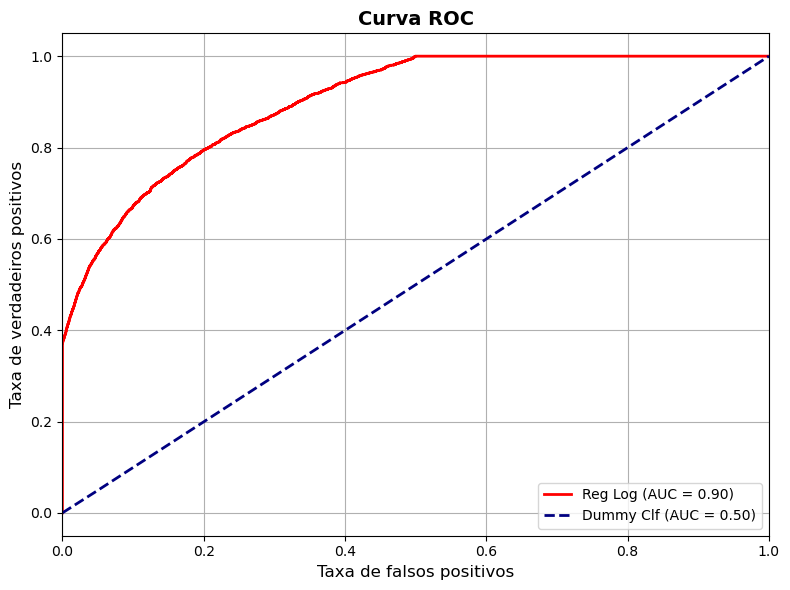

In [26]:
# curva ROC
from sklearn.metrics import roc_curve, auc
fpr_d, tpr_d, thresholds_d = roc_curve(y_train, dummy.predict_proba(X_train)[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, pipe.predict_proba(X_train)[:, 1])

# gráfico
plt.figure(figsize=(8, 6))

# Plot da curva ROC do seu Pipeline
plt.plot(fpr, tpr,
         color='red', 
         linewidth=2,
         label=f'Reg Log (AUC = {auc(fpr, tpr):.2f})')

# Plot da curva ROC do Dummy Classifier
plt.plot(fpr_d, tpr_d,
         color='navy', 
         linestyle='--',
         linewidth=2,
         label=f'Dummy Clf (AUC = {auc(fpr_d, tpr_d):.2f})')

# Configurações do gráfico
plt.xlim([0.0, 1.0])
plt.ylim([-0.05, 1.05])
plt.xlabel('Taxa de falsos positivos', fontsize=12)
plt.ylabel('Taxa de verdadeiros positivos', fontsize=12)
plt.title('Curva ROC', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

### 📊 Métricas de classificação: Precisão, Recall e F1-score

Para além da acurácia, é importante analisar métricas que avaliam diferentes aspectos do modelo:  

- **Precisão (Precision):** entre as instâncias previstas como positivas, quantas realmente eram positivas.  
- **Recall (Sensibilidade):** entre todas as instâncias positivas reais, quantas foram corretamente identificadas.  
- **F1-score:** média harmônica entre precisão e recall, balanceando as duas métricas.  

Aqui comparamos o desempenho do **DummyClassifier** com o modelo treinado,  
para verificar se o modelo realmente traz ganhos nessas métricas fundamentais.


In [28]:
# recall, precisão, f1_score
from sklearn.metrics import precision_score, recall_score, f1_score

prec_dummy, prec_modelo  = precision_score(y_train, dummy.predict(X_train)), precision_score(y_train, pipe.predict(X_train))

rec_dummy, rec_modelo = recall_score(y_train, dummy.predict(X_train)), recall_score(y_train, pipe.predict(X_train))

f1_dummy, f1_modelo = f1_score(y_train, dummy.predict(X_train)), f1_score(y_train, pipe.predict(X_train))

print(f"O modelo dummy obteve precisão de {prec_dummy:.1%}, recall de {rec_dummy:.1%} e f1 de {f1_dummy:.1%}")
print(f"O meu modelo obteve precisão de {prec_modelo:.1%}, recall de {rec_modelo:.1%} e f1 de {f1_modelo:.1%}")

O modelo dummy obteve precisão de 4.8%, recall de 4.7% e f1 de 4.8%
O meu modelo obteve precisão de 14.7%, recall de 83.9% e f1 de 25.0%


### 🧾 Avaliação completa do modelo

Aqui utilizamos diferentes ferramentas para analisar a performance do pipeline treinado:  

- **Matriz de Confusão:** mostra a distribuição das previsões corretas e incorretas.  
- **Relatório de Classificação:** exibe precisão, recall e F1-score para cada classe.  
- **ROC AUC:** avalia a capacidade do modelo de separar as classes em termos probabilísticos.  

Essa combinação de métricas oferece uma visão mais abrangente sobre o desempenho,  
permitindo identificar pontos fortes e fracos do modelo.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = pipe.predict(X_train)

print("Matriz de Confusão:")
print(confusion_matrix(y_train, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_train, y_pred, digits=3))

# Probabilidades para calcular ROC AUC
y_proba = pipe.predict_proba(X_train)[:, 1]
print("\nROC AUC:", roc_auc_score(y_train, y_proba))


Matriz de Confusão:
[[51652 17450]
 [  574  3000]]

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0      0.989     0.747     0.851     69102
         1.0      0.147     0.839     0.250      3574

    accuracy                          0.752     72676
   macro avg      0.568     0.793     0.551     72676
weighted avg      0.948     0.752     0.822     72676



## **Endpoint**

Alcançamos um modelo final de regressão logística e avaliamos ele no conjunto de treinamento. Agora vamos salvar o modelo e avaliá-lo, com os demais, em uma estratégia de validação cruzada final. 

In [24]:
# salvar objeto pipeline completo
joblib.dump(pipeline, 'logreg_pipeline_trained.joblib')

['logreg_pipeline_trained.joblib']